# DATATHON 2026 JUPYTER NOTEBOOK

## Preprocessing

In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene 

#Additional libraries for visualization, correlation analysis, and modeling

df = pd.read_csv("C:\\Users\\Owner\\OneDrive\\Desktop\\Data_Analytics_Practice\\Data@UCI\\Datathon\\ZipData\\ZipData.csv")
df.head(20)

,RecordID,ZipCode,City,County,State,Latitude,Longitude,DominantAreaCode,ResidentialDeliveries,ResidentialPOBoxes,...,MedianHomeValue,MedianAge,MedianAgeMale,MedianAgeFemale,EducationNinthGradeOrLess,EducationSomeHighSchool,EducationHighSchoolGraduate,EducationSomeCollegeWithoutDiploma,EducationAssociatesDegree,EducationBachelorsDegree
0,1,90001,FIRESTONE PARK,LOS ANGELES,CA,33.9740,-118.2494,323,13443,304,...,617000.0,30.7,30.9,30.5,10877,7461,10348,7489,1759,2070
1,2,90001,LOS ANGELES,LOS ANGELES,CA,33.9740,-118.2494,323,13443,304,...,617000.0,30.7,30.9,30.5,10877,7461,10348,7489,1759,2070
2,3,90002,LOS ANGELES,LOS ANGELES,CA,33.9493,-118.2462,323,12443,177,...,606000.0,28.9,28.2,29.6,8540,7883,10074,7595,1499,1759
3,4,90002,WATTS,LOS ANGELES,CA,33.9493,-118.2462,323,12443,177,...,606000.0,28.9,28.2,29.6,8540,7883,10074,7595,1499,1759
4,5,90003,BROADWAY MANCHESTER,LOS ANGELES,CA,33.9634,-118.2742,323,18149,69,...,625000.0,29.0,27.7,30.5,12795,10009,14650,8409,1905,2599
5,6,90003,LOS ANGELES,LOS ANGELES,CA,33.9634,-118.2742,323,18149,69,...,625000.0,29.0,27.7,30.5,12795,10009,14650,8409,1905,2599
6,7,90004,LOS ANGELES,LOS ANGELES,CA,34.0761,-118.3031,323,24686,678,...,1562000.0,35.5,35.3,35.8,6262,4184,10210,7882,2123,12649
7,8,90004,OAKWOOD,LOS ANGELES,CA,34.0761,-118.3031,323,24686,678,...,1562000.0,35.5,35.3,35.8,6262,4184,10210,7882,2123,12649
8,9,90005,LOS ANGELES,LOS ANGELES,CA,34.0590,-118.3024,213,19423,0,...,942000.0,35.6,35.0,36.5,5439,2877,6349,4010,1286,7549
9,10,90005,SANFORD,LOS ANGELES,CA,34.0590,-118.3024,213,19423,0,...,942000.0,35.6,35.0,36.5,5439,2877,6349,4010,1286,7549


In [235]:
print(df.shape)
num_rows, num_columns = df.shape
print(f"The DataFrame has {num_rows} rows and {num_columns} columns.")  # Using f-string for more readable output

(704, 34)
The DataFrame has 704 rows and 34 columns.


In [236]:
new_df = df.iloc[:,[1,2,13,14,15,16,17,18,19,20,21,23,25,26,27,28,29,30,31,32,33]]
new_df.head()

,ZipCode,City,TotalPopulation,PopulationWhite,PopulationAfricanAmerican,PopulationAmericanIndianAlaskaNative,PopulationAsian,PopulationHispanic,PopulationPacificIslander,PopulationOther,...,PerCapitaIncome,MedianAge,MedianAgeMale,MedianAgeFemale,EducationNinthGradeOrLess,EducationSomeHighSchool,EducationHighSchoolGraduate,EducationSomeCollegeWithoutDiploma,EducationAssociatesDegree,EducationBachelorsDegree
0,90001,FIRESTONE PARK,58245,20030,4799,1196,293,52765,70,25981,...,16530.0,30.7,30.9,30.5,10877,7461,10348,7489,1759,2070
1,90001,LOS ANGELES,58245,20030,4799,1196,293,52765,70,25981,...,16530.0,30.7,30.9,30.5,10877,7461,10348,7489,1759,2070
2,90002,LOS ANGELES,54384,17275,9256,1893,627,44082,75,19551,...,15998.0,28.9,28.2,29.6,8540,7883,10074,7595,1499,1759
3,90002,WATTS,54384,17275,9256,1893,627,44082,75,19551,...,15998.0,28.9,28.2,29.6,8540,7883,10074,7595,1499,1759
4,90003,BROADWAY MANCHESTER,75190,16669,12865,709,384,60929,45,33974,...,15605.0,29.0,27.7,30.5,12795,10009,14650,8409,1905,2599


In [237]:
df_gas = pd.read_csv("C:\\Users\\Owner\\OneDrive\\Desktop\\Data_Analytics_Practice\\Data@UCI\\Datathon\\gas_buddy_2022-04-18.csv")
df_gas.head(20)

,services_included,price_time_stamp,currency,postal_code,loc_name,city,review_count,state,zip_code_searched,latitude,...,RUN_START_DATE,source_url,phone,loc_number,price_current,country,longitude,address_1,address_2,overall_rating
0,"Regular, Midgrade, Premium, C-Store, Pay At Pu...",2022-04-17 14:49:58,USD,90001-2731,World,Los Angeles,51.0,CA,90001,33.974931,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/10451,323-582-6158,10451,5.49,USA,-118.237916,1935 E Florence Ave,Wilson Ave,3.8
1,"Regular, Midgrade, Premium, C-Store, Pay At Pu...",2022-04-17 14:49:58,USD,90001-2731,World,Los Angeles,51.0,CA,90001,33.974931,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/10451,323-582-6158,10451,5.59,USA,-118.237916,1935 E Florence Ave,Wilson Ave,3.8
2,"Regular, Midgrade, Premium, C-Store, Pay At Pu...",2022-04-17 14:49:58,USD,90001-2731,World,Los Angeles,51.0,CA,90001,33.974931,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/10451,323-582-6158,10451,5.69,USA,-118.237916,1935 E Florence Ave,Wilson Ave,3.8
3,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.79,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
4,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.69,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
5,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.85,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
6,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.75,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
7,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.95,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
8,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.85,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
9,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,6.09,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9


In [238]:
(df_gas.shape)

(53737, 23)

In [239]:
df_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53737 entries, 0 to 53736
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   services_included  53737 non-null  object 
 1   price_time_stamp   53737 non-null  object 
 2   currency           53737 non-null  object 
 3   postal_code        53699 non-null  object 
 4   loc_name           53737 non-null  object 
 5   city               53737 non-null  object 
 6   review_count       52907 non-null  float64
 7   state              53737 non-null  object 
 8   zip_code_searched  53737 non-null  int64  
 9   latitude           53737 non-null  float64
 10  product_name       53737 non-null  object 
 11  payment_type       53737 non-null  object 
 12  DATE_SCRAPED       53737 non-null  object 
 13  RUN_START_DATE     53737 non-null  object 
 14  source_url         53737 non-null  object 
 15  phone              50483 non-null  object 
 16  loc_number         537

In [240]:
df_gas = df_gas[df_gas['state'] == 'CA']

In [241]:
print(df_gas.shape)

(53703, 23)


In [242]:
df_gas.head(20)

,services_included,price_time_stamp,currency,postal_code,loc_name,city,review_count,state,zip_code_searched,latitude,...,RUN_START_DATE,source_url,phone,loc_number,price_current,country,longitude,address_1,address_2,overall_rating
0,"Regular, Midgrade, Premium, C-Store, Pay At Pu...",2022-04-17 14:49:58,USD,90001-2731,World,Los Angeles,51.0,CA,90001,33.974931,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/10451,323-582-6158,10451,5.49,USA,-118.237916,1935 E Florence Ave,Wilson Ave,3.8
1,"Regular, Midgrade, Premium, C-Store, Pay At Pu...",2022-04-17 14:49:58,USD,90001-2731,World,Los Angeles,51.0,CA,90001,33.974931,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/10451,323-582-6158,10451,5.59,USA,-118.237916,1935 E Florence Ave,Wilson Ave,3.8
2,"Regular, Midgrade, Premium, C-Store, Pay At Pu...",2022-04-17 14:49:58,USD,90001-2731,World,Los Angeles,51.0,CA,90001,33.974931,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/10451,323-582-6158,10451,5.69,USA,-118.237916,1935 E Florence Ave,Wilson Ave,3.8
3,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.79,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
4,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.69,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
5,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.85,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
6,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.75,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
7,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.95,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
8,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,5.85,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9
9,"Regular, Midgrade, Premium, Diesel, Offers Cas...",2022-04-17 14:49:43,USD,90011,7-Eleven,Los Angeles,27.0,CA,90001,33.989139,...,2022-04-18T05:01:23+8:00,https://www.gasbuddy.com/Station/200973,NaN,200973,6.09,USA,-118.251866,1302 E Slauson Ave,Hooper Ave,3.9


In [243]:
df_gas.rename(columns={'zip_code_searched': 'ZipCode'}, inplace=True)

In [244]:
df_gas = df_gas.drop(columns = ['city', 'review_count', 'services_included', 'price_time_stamp', 'currency', 'postal_code', 'latitude', 'DATE_SCRAPED', 'RUN_START_DATE',
                     'source_url', 'phone', 'loc_number', 'country', 'longitude', 'address_1', 'address_2', 'payment_type', 'state', 'overall_rating'])
df_gas.head(20)

,loc_name,ZipCode,product_name,price_current
0,World,90001,Regular,5.49
1,World,90001,Midgrade,5.59
2,World,90001,Premium,5.69
3,7-Eleven,90001,Regular,5.79
4,7-Eleven,90001,Regular,5.69
5,7-Eleven,90001,Midgrade,5.85
6,7-Eleven,90001,Midgrade,5.75
7,7-Eleven,90001,Premium,5.95
8,7-Eleven,90001,Premium,5.85
9,7-Eleven,90001,Diesel,6.09


In [245]:
df_pivoted = df_gas.pivot_table(index='ZipCode', columns='product_name', values='price_current', aggfunc='mean').reset_index()
df_pivoted

product_name,ZipCode,Diesel,E85,Midgrade,Premium,Regular,UNL88
0,90001,3.907500,2.145,4.453282,4.497863,4.441985,NaN
1,90002,4.683913,3.690,4.746000,4.850000,4.578750,NaN
2,90003,6.462000,NaN,3.481538,3.589231,4.260000,NaN
3,90004,5.924333,NaN,5.329845,5.430930,5.299077,NaN
4,90005,5.263125,3.690,5.013243,5.119189,5.028919,NaN
...,...,...,...,...,...,...,...
542,96106,0.000000,NaN,0.000000,0.000000,0.000000,NaN
543,96107,0.000000,NaN,0.000000,0.000000,0.000000,NaN
544,96109,3.095000,NaN,0.000000,0.000000,2.795000,NaN
545,96114,3.079000,NaN,2.255000,2.355000,3.810000,NaN


In [246]:
print(df_pivoted.shape)

(547, 7)


In [247]:
df_pivoted = df_pivoted.drop(columns=['Diesel','E85', 'UNL88'])

In [248]:
df_gas.head()

,loc_name,ZipCode,product_name,price_current
0,World,90001,Regular,5.49
1,World,90001,Midgrade,5.59
2,World,90001,Premium,5.69
3,7-Eleven,90001,Regular,5.79
4,7-Eleven,90001,Regular,5.69


In [249]:
df_gas = pd.merge(df_gas, df_pivoted, on='ZipCode', how='left')

In [250]:
df_gas.drop_duplicates(subset='ZipCode', inplace=True)

In [251]:
print(df_pivoted.shape)
df_pivoted.head()

(547, 4)


product_name,ZipCode,Midgrade,Premium,Regular
0,90001,4.453282,4.497863,4.441985
1,90002,4.746000,4.850000,4.578750
2,90003,3.481538,3.589231,4.260000
3,90004,5.329845,5.430930,5.299077
4,90005,5.013243,5.119189,5.028919


In [252]:
df_gas = pd.merge(new_df, df_gas, on='ZipCode', how='left')

In [253]:
df_gas = df_gas.dropna(subset=['Regular'])

In [254]:
df_gas = df_gas.drop(columns=['City'])

In [255]:
df_gas = df_gas.drop_duplicates()

In [256]:
print(df_gas.shape)

(131, 26)


In [257]:
print(df_gas.isnull().sum())

ZipCode                                 0
TotalPopulation                         0
PopulationWhite                         0
PopulationAfricanAmerican               0
PopulationAmericanIndianAlaskaNative    0
PopulationAsian                         0
PopulationHispanic                      0
PopulationPacificIslander               0
PopulationOther                         0
PopulationMultipleRace                  0
PerCapitaIncome                         0
MedianAge                               0
MedianAgeMale                           0
MedianAgeFemale                         0
EducationNinthGradeOrLess               0
EducationSomeHighSchool                 0
EducationHighSchoolGraduate             0
EducationSomeCollegeWithoutDiploma      0
EducationAssociatesDegree               0
EducationBachelorsDegree                0
loc_name                                0
product_name                            0
price_current                           0
Midgrade                          

In [258]:
df_gas = df_gas.dropna(subset=['Premium'])

In [259]:
print(df_gas.shape)

(130, 26)


In [260]:
df_gas.head()

,ZipCode,TotalPopulation,PopulationWhite,PopulationAfricanAmerican,PopulationAmericanIndianAlaskaNative,PopulationAsian,PopulationHispanic,PopulationPacificIslander,PopulationOther,PopulationMultipleRace,...,EducationHighSchoolGraduate,EducationSomeCollegeWithoutDiploma,EducationAssociatesDegree,EducationBachelorsDegree,loc_name,product_name,price_current,Midgrade,Premium,Regular
0,90001,58245,20030,4799,1196,293,52765,70,25981,5876,...,10348,7489,1759,2070,World,Regular,5.49,4.453282,4.497863,4.441985
2,90002,54384,17275,9256,1893,627,44082,75,19551,5707,...,10074,7595,1499,1759,Us Gasoline,Regular,5.29,4.746000,4.850000,4.578750
4,90003,75190,16669,12865,709,384,60929,45,33974,10544,...,14650,8409,1905,2599,ARCO,Regular,5.25,3.481538,3.589231,4.260000
6,90004,59621,17681,2448,446,15224,28019,104,19907,3811,...,10210,7882,2123,12649,76,Regular,5.65,5.329845,5.430930,5.299077
8,90005,36910,7616,2180,325,12212,18134,18,10302,4257,...,6349,4010,1286,7549,Shell,Regular,5.85,5.013243,5.119189,5.028919


Write df_gas into a csv file and plug into Omni

In [261]:
df_gas_file = df_gas.to_csv("C:\\Users\\Owner\\OneDrive\\Desktop\\Data_Analytics_Practice\\Data@UCI\\Datathon\\df_gas.csv", index=False)

## Data Visualization and Correlation Analysis

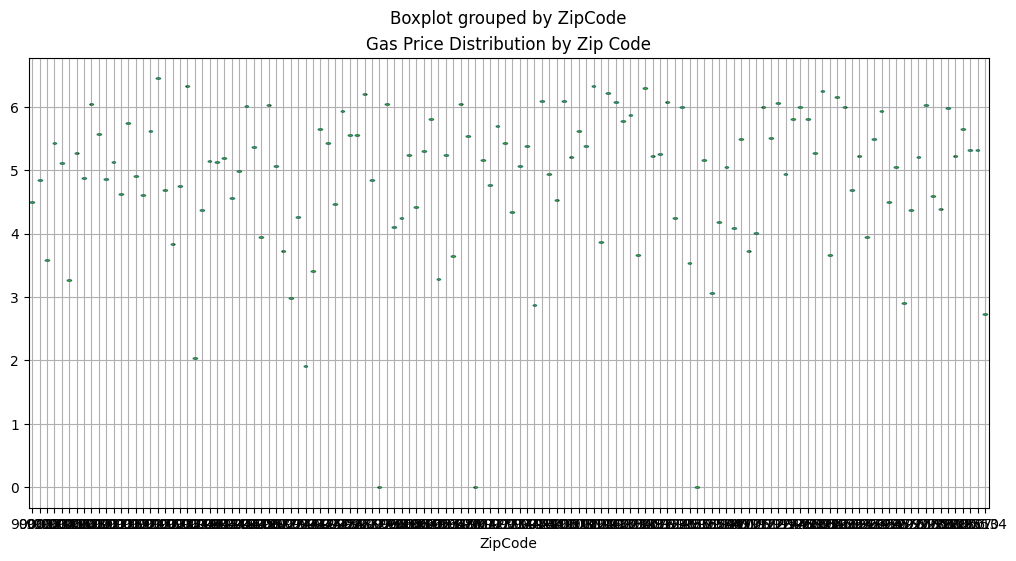

In [262]:
df_gas.boxplot(column='Premium', by='ZipCode', figsize=(12, 6))
plt.title('Gas Price Distribution by Zip Code')
plt.show()

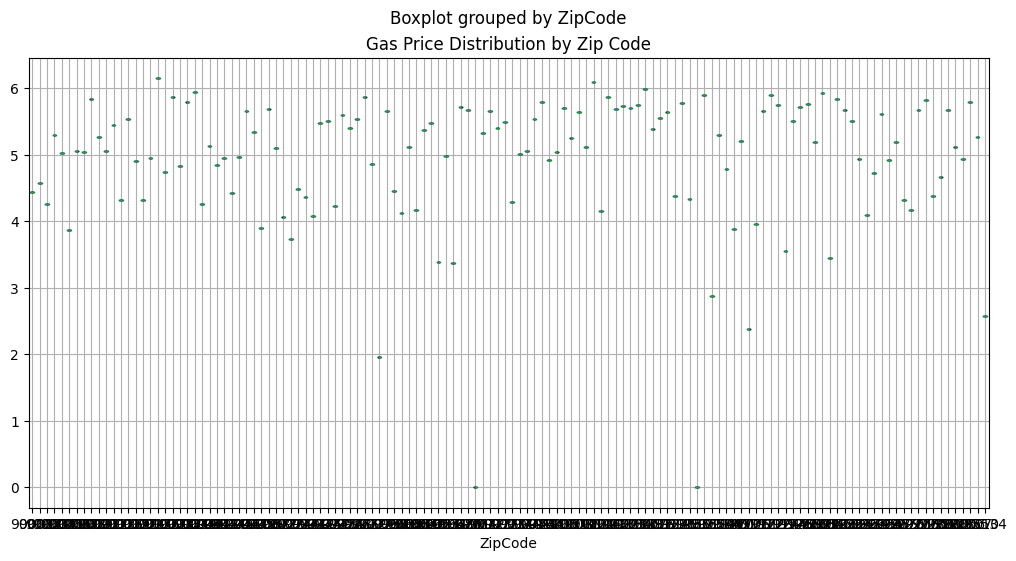

In [263]:
df_gas.boxplot(column='Regular', by='ZipCode', figsize=(12, 6))
plt.title('Gas Price Distribution by Zip Code')
plt.show()

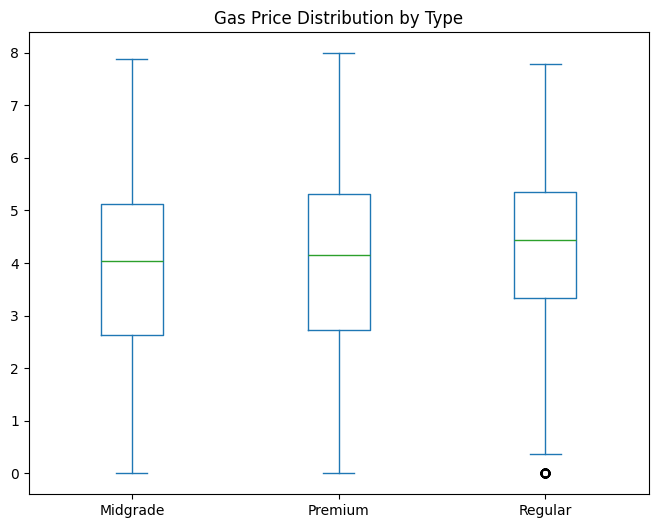

In [264]:
df_pivoted[['Midgrade', 'Premium', 'Regular']].plot(kind='box', figsize=(8, 6))
plt.title('Gas Price Distribution by Type')
plt.show()

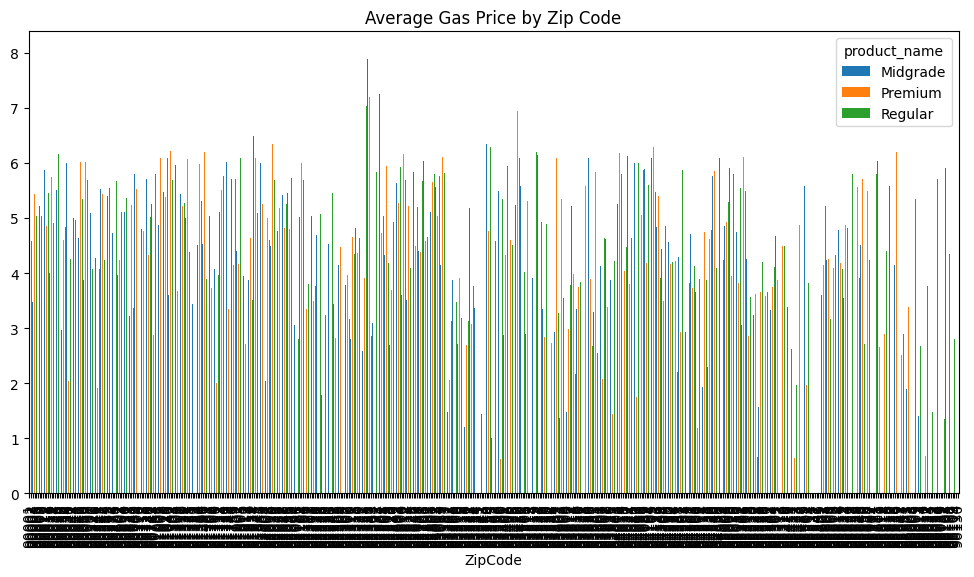

In [265]:
df_pivoted.groupby('ZipCode')[['Midgrade', 'Premium', 'Regular']].mean().plot(kind='bar', figsize=(12, 6))
plt.title('Average Gas Price by Zip Code')
plt.show()

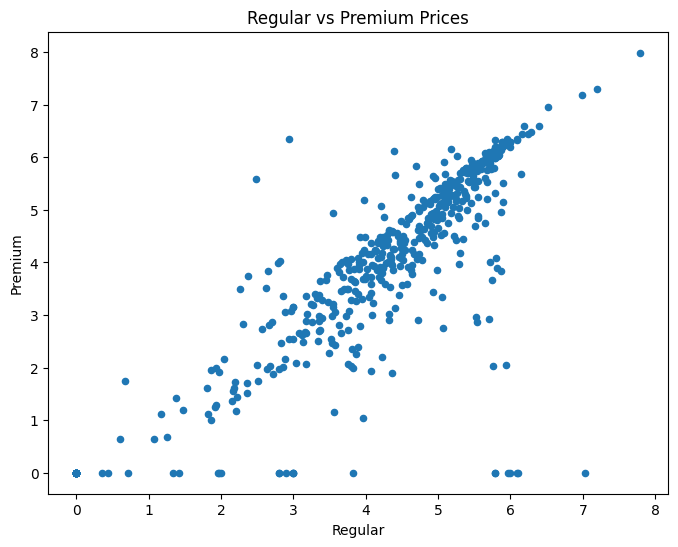

In [266]:
df_pivoted.plot(kind='scatter', x='Regular', y='Premium', figsize=(8, 6))
plt.title('Regular vs Premium Prices')
plt.show()

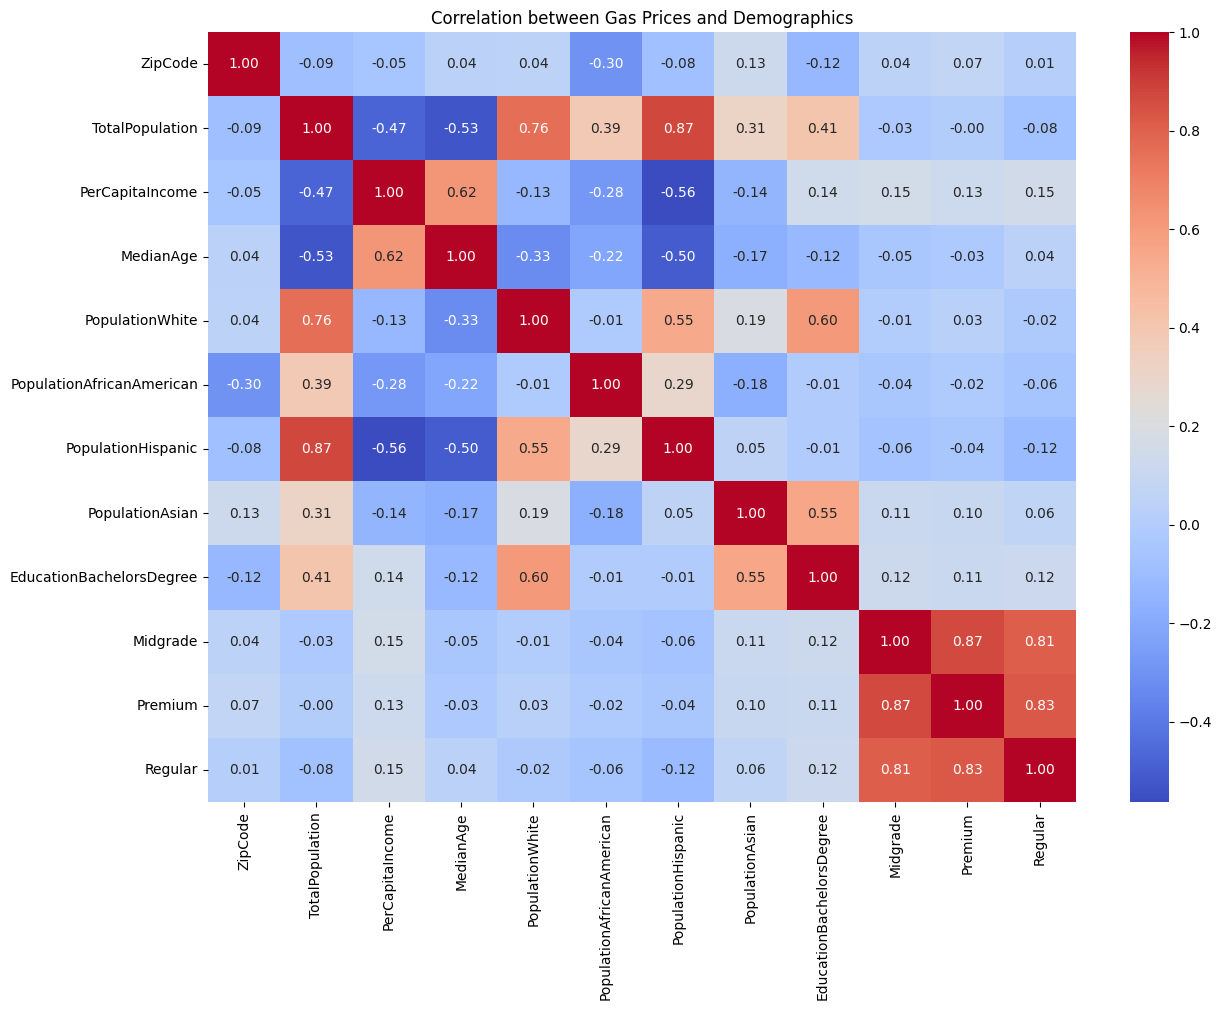

In [267]:
cols = ['ZipCode','TotalPopulation', 'PerCapitaIncome',
        'MedianAge', 'PopulationWhite', 'PopulationAfricanAmerican',
        'PopulationHispanic', 'PopulationAsian', 'EducationBachelorsDegree',
        'Midgrade','Premium','Regular']
plt.figure(figsize=(14, 10))
sns.heatmap(df_gas[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between Gas Prices and Demographics')
plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_2808\1043906299.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_gas.groupby('IncomeGroup')[['Regular', 'Midgrade', 'Premium']].mean().plot(kind='bar')


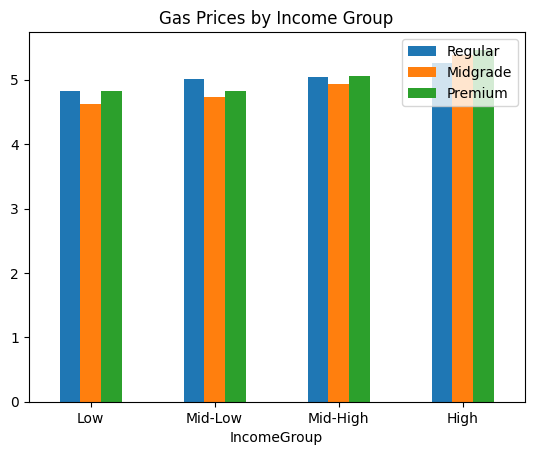

In [268]:
df_gas['IncomeGroup'] = pd.cut(df['PerCapitaIncome'], bins=4,
                            labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

df_gas.groupby('IncomeGroup')[['Regular', 'Midgrade', 'Premium']].mean().plot(kind='bar')
plt.xticks(rotation=0)
plt.title('Gas Prices by Income Group')
plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_2808\841851544.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_gas.groupby('IncomeGroup')[['Regular', 'Midgrade', 'Premium']].agg(['mean', 'std']).plot(kind='bar')
C:\Users\Owner\AppData\Local\Temp\ipykernel_2808\841851544.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_gas.groupby('IncomeGroup')[['Regular', 'Midgrade', 'Premium']].mean()
C:\Users\Owner\AppData\Local\Temp\ipykernel_2808\841851544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

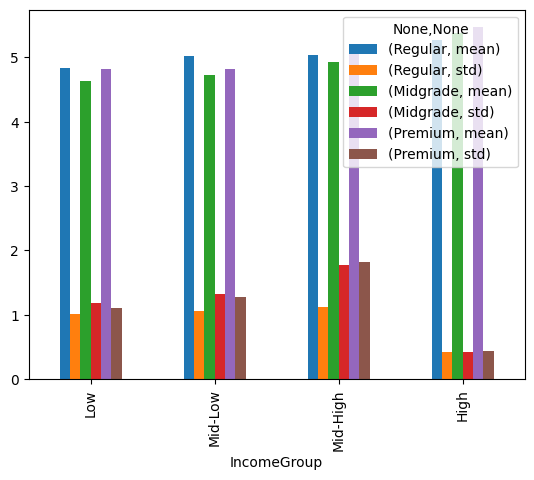

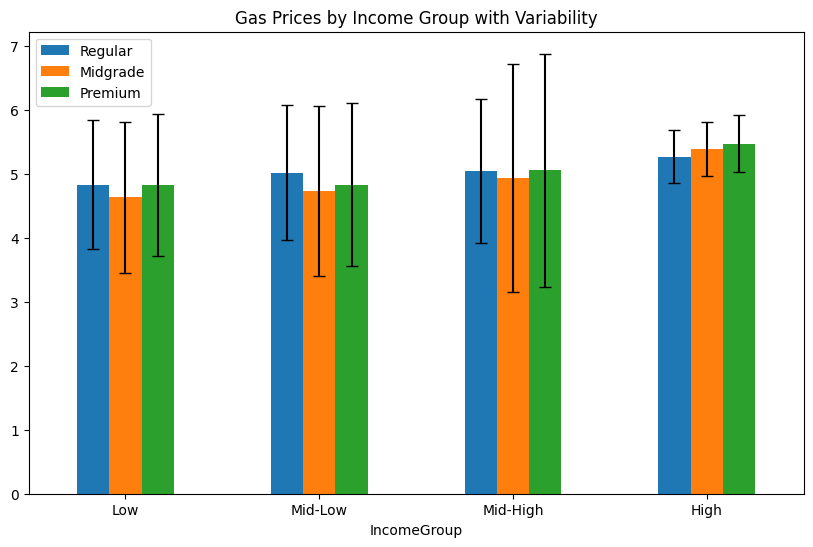

In [269]:
df_gas.groupby('IncomeGroup')[['Regular', 'Midgrade', 'Premium']].agg(['mean', 'std']).plot(kind='bar')

# Or manually with error bars
means = df_gas.groupby('IncomeGroup')[['Regular', 'Midgrade', 'Premium']].mean()
errors = df_gas.groupby('IncomeGroup')[['Regular', 'Midgrade', 'Premium']].std()

means.plot(kind='bar', yerr=errors, figsize=(10, 6), capsize=4)
plt.title('Gas Prices by Income Group with Variability')
plt.xticks(rotation=0)
plt.show()

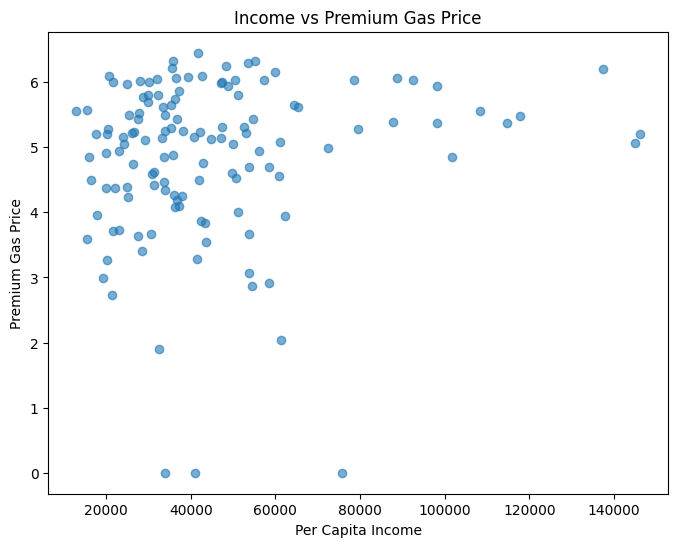

In [270]:
plt.figure(figsize=(8, 6))
plt.scatter(df_gas['PerCapitaIncome'], df_gas['Premium'], alpha=0.6)
plt.xlabel('Per Capita Income')
plt.ylabel('Premium Gas Price')
plt.title('Income vs Premium Gas Price')
plt.show()

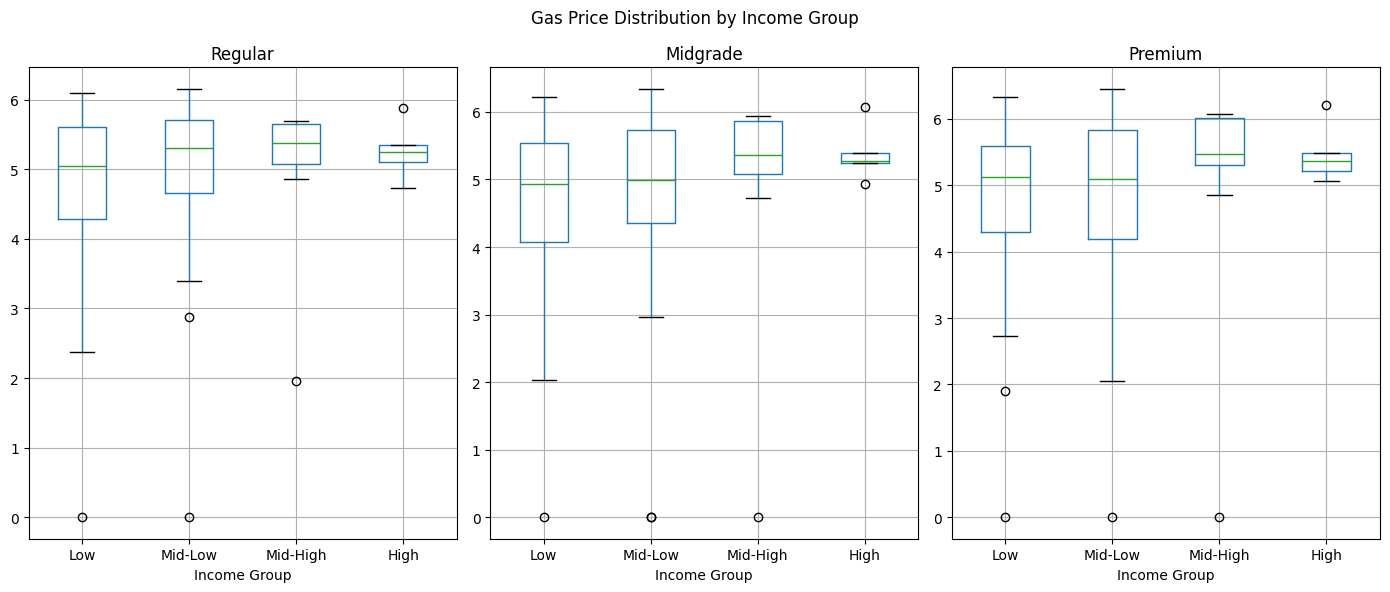

In [271]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, col in zip(axes, ['Regular', 'Midgrade', 'Premium']):
    df_gas.boxplot(column=col, by='IncomeGroup', ax=ax)
    ax.set_title(col.capitalize())
    ax.set_xlabel('Income Group')

plt.suptitle('Gas Price Distribution by Income Group')
plt.tight_layout()
plt.show()

## MODEL TESTING

In [272]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = df_gas[['PerCapitaIncome', 'MedianAge', 'TotalPopulation',
        'PopulationWhite', 'PopulationHispanic', 'EducationBachelorsDegree']]
y = df_gas['Regular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [274]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)
print(r2_score(y_test, model.predict(X_test)))

0.22129009543851919


In [275]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

df_gas['IncomeGroup'] = pd.cut(df_gas['PerCapitaIncome'], bins=4,
                               labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

X_gas = df_gas[['Regular', 'Midgrade', 'Premium']]

le = LabelEncoder()
y_gas = le.fit_transform(df_gas['IncomeGroup'])

X_train, X_test, y_train, y_test = train_test_split(X_gas, y_gas, test_size=0.2, random_state=42)

nb_gas_model = GaussianNB()
nb_gas_model.fit(X_train, y_train)
y_pred_gas = nb_gas_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_gas):.3f}\n")
print(classification_report(y_test, y_pred_gas, target_names=le.classes_))




Accuracy: 0.346

              precision    recall  f1-score   support

        High       0.00      0.00      0.00         1
         Low       0.75      0.47      0.58        19
    Mid-High       0.00      0.00      0.00         0
     Mid-Low       0.00      0.00      0.00         6

    accuracy                           0.35        26
   macro avg       0.19      0.12      0.15        26
weighted avg       0.55      0.35      0.42        26



c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: 